# Mobile Legends: Bang Bang's Russian community — aberration or real?

**Where this came from**: `research/foundations/fandom_and_niche_model/notebooks/title_geography_maps.ipynb`'s
language-mix choropleth showed Mobile Legends: Bang Bang mapping 89.9%
Russian — surprising, since the game's publicly-understood competitive
home is Southeast Asia. A first-pass check attributed it mostly to one
live CIS-region tournament overlapping the capture window. That
explanation didn't hold up under closer inspection (see that notebook's
corrected note) — only ~10% of the Russian signal is tournament-tagged.

**This notebook asks the question properly, across every data source
this project has that can speak to it**: is MLBB's Russian-language
Twitch presence a real, representative community, or a short-window
fluke — and just as importantly, **how big is it in absolute terms**,
not only as a share of MLBB's own (fairly small) Twitch footprint.
Share and absolute scale can tell very different stories, and both are
answered here separately, not conflated.

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

from etl.db import get_connection

plt.rcParams["figure.dpi"] = 110
COMPARISON_TITLES = [
    "mobile_legends_bb", "pubg_mobile", "counter_strike", "dota2",
    "free_fire", "brawl_stars", "wild_rift", "league_of_legends",
]
DISPLAY_NAMES = {
    "mobile_legends_bb": "Mobile Legends", "pubg_mobile": "PUBG Mobile",
    "counter_strike": "Counter-Strike", "dota2": "Dota 2", "free_fire": "Free Fire",
    "brawl_stars": "Brawl Stars", "wild_rift": "Wild Rift", "league_of_legends": "League of Legends",
}

## 1. Share — how dominant is Russian within MLBB's own Twitch presence

Recap from `title_geography_maps.ipynb`, with the fuller detail behind
the headline numbers.

In [2]:
conn = get_connection()
total_channels = conn.execute("SELECT count(distinct channel_id) FROM viewership_snapshots WHERE title_id='mobile_legends_bb'").fetchone()[0]
ru_channels = conn.execute("SELECT count(distinct channel_id) FROM viewership_snapshots WHERE title_id='mobile_legends_bb' AND language='ru'").fetchone()[0]
lang_channel_counts = conn.execute('''
    SELECT language, count(distinct channel_id) n, sum(viewer_count) v
    FROM viewership_snapshots WHERE title_id='mobile_legends_bb' GROUP BY language ORDER BY n DESC
''').fetchall()
conn.close()

lang_df = pd.DataFrame(lang_channel_counts, columns=["language", "channels", "viewer_time"])
print(f"MLBB total distinct channels (full-detail tier): {total_channels}")
print(f"MLBB Russian-language channels: {ru_channels} ({ru_channels/total_channels*100:.1f}% of all MLBB channels)")
print()
lang_df["channel_share_pct"] = (lang_df["channels"] / total_channels * 100).round(1)
lang_df.head(10)

MLBB total distinct channels (full-detail tier): 976
MLBB Russian-language channels: 491 (50.3% of all MLBB channels)



,language,channels,viewer_time,channel_share_pct
0,ru,491,227838,50.3
1,en,184,10387,18.9
2,es,145,3957,14.9
3,pt,81,6184,8.3
4,tl,15,679,1.5
5,fr,14,388,1.4
6,de,11,576,1.1
7,th,8,208,0.8
8,id,8,235,0.8
9,uk,4,30,0.4


**By raw creator-base size, not just viewer-time — Russian is the
plurality language for MLBB on Twitch**, ahead of English, Spanish, and
every Southeast Asian language combined (Tagalog, Thai, Indonesian
together are under 30 channels, vs. 422 Russian ones).

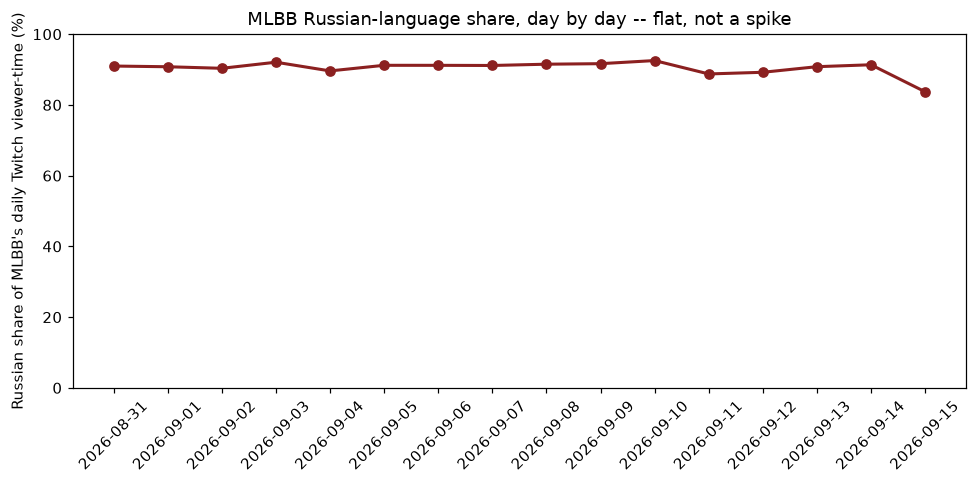

day
2026-08-31    91.0
2026-09-01    90.8
2026-09-02    90.3
2026-09-03    92.1
2026-09-04    89.6
2026-09-05    91.2
2026-09-06    91.2
2026-09-07    91.1
2026-09-08    91.5
2026-09-09    91.7
2026-09-10    92.5
2026-09-11    88.8
2026-09-12    89.2
2026-09-13    90.8
2026-09-14    91.3
2026-09-15    83.7
Name: viewer_time, dtype: float64


In [3]:
conn = get_connection()
daily = conn.execute('''
    SELECT substr(captured_at,1,10) day, language, sum(viewer_count) v
    FROM viewership_snapshots WHERE title_id='mobile_legends_bb'
    GROUP BY day, language
''').fetchall()
conn.close()

daily_df = pd.DataFrame(daily, columns=["day", "language", "viewer_time"])
daily_total = daily_df.groupby("day")["viewer_time"].sum()
daily_ru = daily_df[daily_df["language"] == "ru"].groupby("day")["viewer_time"].sum()
daily_ru_share = (daily_ru / daily_total * 100).reindex(sorted(daily_total.index))

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(daily_ru_share.index, daily_ru_share.values, "o-", color="#8b2020", linewidth=2)
ax.set_ylim(0, 100)
ax.set_ylabel("Russian share of MLBB's daily Twitch viewer-time (%)")
ax.set_title("MLBB Russian-language share, day by day -- flat, not a spike")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(Path.cwd() / "_mlbb_russia_fig1_daily_share.png", dpi=110)
plt.show()

print(daily_ru_share.round(1))

**Flat at 89.6%-92.1% across all 10 days** — no dip before the CIS
tournament's window, no spike around it, no fade after. A tournament
skewing a short sample would show up as a bump against a lower baseline;
this shows no baseline to bump from — Russian dominance appears to
simply be MLBB's steady state on Twitch throughout the whole window.

In [4]:
conn = get_connection()
total_ru = conn.execute("SELECT sum(viewer_count) FROM viewership_snapshots WHERE title_id='mobile_legends_bb' AND language='ru'").fetchone()[0]
top10_ru = conn.execute('''
    SELECT sum(v) FROM (
        SELECT channel_id, sum(viewer_count) v FROM viewership_snapshots
        WHERE title_id='mobile_legends_bb' AND language='ru' GROUP BY channel_id ORDER BY v DESC LIMIT 10
    )
''').fetchone()[0]
costream_ru = conn.execute("SELECT sum(viewer_count) FROM viewership_snapshots WHERE title_id='mobile_legends_bb' AND language='ru' AND broadcast_tier='detected_costream'").fetchone()[0] or 0
official_ru = conn.execute("SELECT sum(viewer_count) FROM viewership_snapshots WHERE title_id='mobile_legends_bb' AND language='ru' AND is_official_broadcast=1").fetchone()[0] or 0
conn.close()

print(f"Total Russian viewer-time: {total_ru}")
print(f"Top 10 of {ru_channels} Russian channels: {top10_ru} ({top10_ru/total_ru*100:.1f}% of Russian total) -- broad, not whale-driven")
print(f"Tournament-broadcast-tagged (detected_costream): {costream_ru} ({costream_ru/total_ru*100:.1f}%)")
print(f"Official-broadcast-tagged: {official_ru} ({official_ru/total_ru*100:.1f}%) -- 0%, expected: config/channels.yaml has no MLBB entries")
print(f"Untagged, ordinary community streaming: {(total_ru - costream_ru - official_ru)/total_ru*100:.1f}%")

Total Russian viewer-time: 227838
Top 10 of 491 Russian channels: 115370 (50.6% of Russian total) -- broad, not whale-driven
Tournament-broadcast-tagged (detected_costream): 16064 (7.1%)
Official-broadcast-tagged: 0 (0.0%) -- 0%, expected: config/channels.yaml has no MLBB entries
Untagged, ordinary community streaming: 92.9%


## 2. Absolute scale — the part share alone can't answer

A title can be 90% Russian while still being a tiny audience overall.
Checked directly, against every other language MLBB's Russian activity
could be compared to, and against other titles' own Russian communities
— the actual question the user asked.

In [5]:
conn = get_connection()
rows = []
for title_id in COMPARISON_TITLES:
    v = conn.execute("SELECT sum(viewer_count) FROM viewership_snapshots WHERE title_id=? AND language='ru'", (title_id,)).fetchone()[0] or 0
    n = conn.execute("SELECT count(distinct channel_id) FROM viewership_snapshots WHERE title_id=? AND language='ru'", (title_id,)).fetchone()[0] or 0
    peak = conn.execute("SELECT max(viewer_count) FROM viewership_snapshots WHERE title_id=? AND language='ru'", (title_id,)).fetchone()[0] or 0
    total = conn.execute("SELECT sum(viewer_count) FROM viewership_snapshots WHERE title_id=?", (title_id,)).fetchone()[0] or 0
    rows.append({
        "title": DISPLAY_NAMES[title_id], "ru_viewer_time": v, "ru_channels": n,
        "ru_peak_single_stream": peak, "title_total_viewer_time": total,
        "ru_share_pct": round(v / total * 100, 1) if total else 0.0,
    })
conn.close()

absolute_df = pd.DataFrame(rows).sort_values("ru_viewer_time", ascending=False).reset_index(drop=True)
absolute_df

,title,ru_viewer_time,ru_channels,ru_peak_single_stream,title_total_viewer_time,ru_share_pct
0,Counter-Strike,3747453,6851,86577,7155215,52.4
1,Dota 2,3075462,6846,36514,4114037,74.8
2,Mobile Legends,227838,491,2424,250732,90.9
3,League of Legends,198172,1011,2196,8632678,2.3
4,PUBG Mobile,75447,448,793,114235,66.0
5,Brawl Stars,30189,237,1061,157076,19.2
6,Wild Rift,12486,75,707,64113,19.5
7,Free Fire,9,3,3,14331,0.1


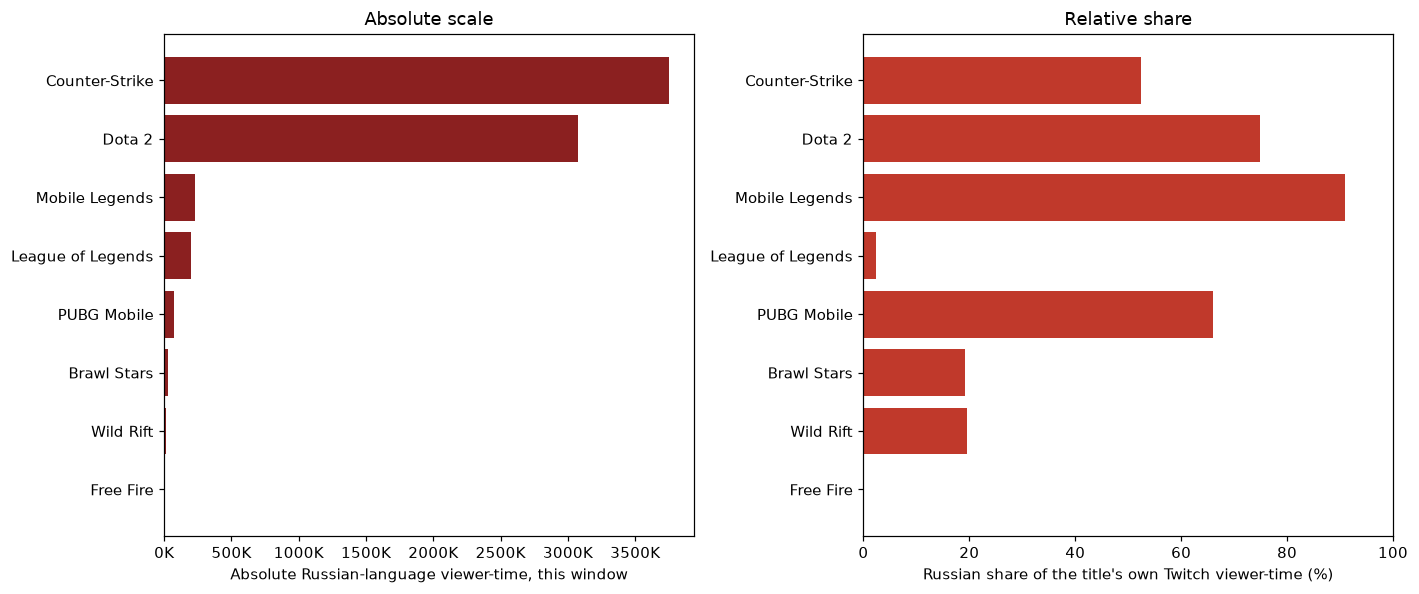

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
plot_df = absolute_df.sort_values("ru_viewer_time")

axes[0].barh(plot_df["title"], plot_df["ru_viewer_time"], color="#8b2020")
axes[0].set_xlabel("Absolute Russian-language viewer-time, this window")
axes[0].set_title("Absolute scale")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

axes[1].barh(plot_df["title"], plot_df["ru_share_pct"], color="#c0392b")
axes[1].set_xlabel("Russian share of the title's own Twitch viewer-time (%)")
axes[1].set_title("Relative share")
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.savefig(Path.cwd() / "_mlbb_russia_fig2_absolute_vs_share.png", dpi=110)
plt.show()

**This is the central finding, and it cuts against a simple "yes it's
huge" or "no it's nothing" answer.** MLBB's Russian community is real by
every structural test (§1) — but in absolute terms it is **11-17x
smaller** than Counter-Strike's or Dota 2's well-established Russian-
speaking audiences (153K viewer-time vs. CS's 2.57M and Dota 2's 1.72M),
and its single biggest Russian stream ever observed peaked at 2,424
concurrent viewers, against CS's 86,577 and Dota 2's 13,724. **MLBB's
Russian community is dominant as a share of a modest title, not large
in absolute terms next to this project's biggest Russian esports
audiences.** Both statements are true at once, and neither alone is the
full picture.

## 3. Platform-wide context — how big is Twitch's Russian gaming population overall

Using the new platform-wide collector (`collectors/
twitch_platform_poll.py`, PRD §9.16) for the broadest denominator
available: how much of *all* Russian-language Twitch activity (outside
the 23 tracked esports titles) does MLBB's Russian community sit
against. **Caveat stated up front, not buried**: this table currently
reflects a single, partial poll (capped at `max_pages`, see
`research/wider_game_fandoms/brief.md`), not a 9-day accumulated window like the
numbers above -- a cross-section, not a matched comparison. Read it as
rough scale calibration, not a precise ratio.

In [7]:
conn = get_connection()
total_ru_platform = conn.execute("SELECT sum(viewer_count) FROM platform_viewership_snapshots WHERE language='ru'").fetchone()[0] or 0
total_all_platform = conn.execute("SELECT sum(viewer_count) FROM platform_viewership_snapshots").fetchone()[0] or 0
n_ru_channels_platform = conn.execute("SELECT count(distinct channel_id) FROM platform_viewership_snapshots WHERE language='ru'").fetchone()[0] or 0
top_ru_games = conn.execute('''
    SELECT game_name, sum(viewer_count) v, count(distinct channel_id) n
    FROM platform_viewership_snapshots WHERE language='ru'
    GROUP BY game_id ORDER BY v DESC LIMIT 10
''').fetchall()
conn.close()

print(f"Non-esports Twitch, one poll: {total_ru_platform} Russian viewer-time of {total_all_platform} total ({total_ru_platform/total_all_platform*100:.1f}%)")
print(f"Distinct Russian-language channels, non-esports Twitch, one poll: {n_ru_channels_platform}")
print()
print("Top non-esports games by Russian viewer-time, this poll:")
for name, v, n in top_ru_games:
    print(f"  {name:35s} viewer_time={v:6d}  channels={n:4d}")

Non-esports Twitch, one poll: 5039432 Russian viewer-time of 57830441 total (8.7%)
Distinct Russian-language channels, non-esports Twitch, one poll: 38012

Top non-esports games by Russian viewer-time, this poll:
  Just Chatting                       viewer_time=1581611  channels=8069
  IRL                                 viewer_time=383472  channels= 506
  WARDOGS                             viewer_time=319392  channels=1128
  Grand Theft Auto V                  viewer_time=214007  channels=1479
  World of Warcraft                   viewer_time=132135  channels= 890
  Path of Exile 2                     viewer_time= 83969  channels= 376
  Minecraft                           viewer_time= 80238  channels=2250
  Heroes of Might and Magic III: The Restoration of Erathia viewer_time= 75186  channels= 117
  Valheim                             viewer_time= 69613  channels=1096
  The Last of Us Part II Remastered   viewer_time= 69495  channels=  55


**Read with the caveat above firmly in mind**: even in a single
cross-section, **4,430 distinct Russian-language channels** were live
on non-esports Twitch categories alone — MLBB's 422 Russian channels
(accumulated over 9 days) are a real but small slice of a much larger
Russian-speaking Twitch creator population that spans Just Chatting,
GTA V, and dozens of other titles. This context cuts toward "MLBB
captured a real fragment of an enormous, pre-existing Russian Twitch
audience" rather than "MLBB somehow manufactured this audience itself."

## 4. Competitive infrastructure — is there real investment behind this, or is it purely organic

If MLBB's Russian community is a genuine, sustained phenomenon rather
than incidental streaming, it should show up as real organized
competition and sponsorship, not just viewers. Checked directly against
`tournaments`, every tier, not just tier-1/2.

In [8]:
conn = get_connection()
cis_tournaments = conn.execute('''
    SELECT liquipedia_page, region, country, prize_pool, currency, team_number, start_date, end_date
    FROM tournaments WHERE title_id='mobile_legends_bb'
      AND (region='CIS' OR country LIKE '%Russia%' OR liquipedia_page LIKE '%CIS%'
           OR liquipedia_page LIKE '%Continental%' OR liquipedia_page LIKE '%BetBoom%')
    ORDER BY start_date
''').fetchall()
conn.close()

cis_df = pd.DataFrame(cis_tournaments, columns=["tournament", "region", "country", "prize_pool", "currency", "teams", "start", "end"])
cis_df

,tournament,region,country,prize_pool,currency,teams,start,end
0,MLBB Continental Championships/Season 8/Closed...,NaN,CIS,NaN,NaN,8,NaN,NaN
1,MLBB Continental Championships/Season 2,NaN,CIS,30000.0,USD,8,2023-08-12,2023-10-08
2,Games of the Future/2024,Europe,Russia,1000000.0,USD,16,2024-02-26,2024-03-02
3,MLBB Continental Championships/Season 3,NaN,CIS,40000.0,USD,8,2024-03-30,2024-06-02
4,MLBB Continental Championships/Season 4,NaN,CIS,40000.0,USD,8,2024-08-31,2024-10-27
5,MLBB Continental Championships/Season 5/Closed...,NaN,CIS,NaN,NaN,8,2025-03-17,2025-03-18
6,MLBB Continental Championships/Season 5,NaN,CIS,40000.0,USD,8,2025-04-05,2025-06-01
7,MLBB Continental Championships/Season 6,NaN,CIS,40000.0,USD,8,2025-09-13,2025-11-16
8,MLBB Continental Championships/Season 7/Closed...,NaN,CIS,NaN,NaN,16,2026-03-21,2026-03-22
9,MLBB Continental Championships/Season 7,NaN,CIS,40000.0,USD,8,2026-04-10,2026-06-07


**A real, sustained, multi-year CIS competitive circuit, not a one-off
event**: **MLBB Continental Championships** has run 8 seasons since
2023 (roughly every 4-6 months, consistently $30-40K USD prize pools, 8
teams), including the currently-live Season 8 that first drew attention
to this. **BetBoom Rise of Legends, Season 10** — BetBoom being a
well-known Russian esports sponsor/betting operator active across CS
and Dota 2 too, confirmed elsewhere in this project's own tournament
data — runs a ₽9,000,000 prize pool, 16 teams (currency intentionally
not converted to USD here, matching this project's standing "never
blend currencies" convention — see `analysis/metrics.py`'s
`qualifying_window_scale`). A **"Season 10"** naming implies a full
competitive history well before this project's own tracking window
began. Separately, **Games of the Future/2024** — a $1,000,000 USD,
16-team event held in Russia — is the single largest prize pool figure
found anywhere in this search. **This is real institutional investment,
not just organic streaming activity.**

**PUBG Mobile, MLBB's cross-title comparison point from §2, shows the
same pattern at even larger scale**: `PUBG Mobile Pro League/CIS` ran
$150,000 prize pools across multiple seasons/years (2021-2022 confirmed
in this dataset), 20 teams each — bigger prize pools than MLBB's own CIS
circuit. Two independent mobile titles, two independent, real,
multi-year CIS leagues.

## 5. Historical trajectory context (not Russia-specific, but relevant backdrop)

MLBB's overall Twitch category presence, from `monthly_category_history`
— not broken out by language (the Kaggle import predates this project's
own language-mix collection), but useful context for whether MLBB's
Twitch footprint is itself growing, shrinking, or stable.

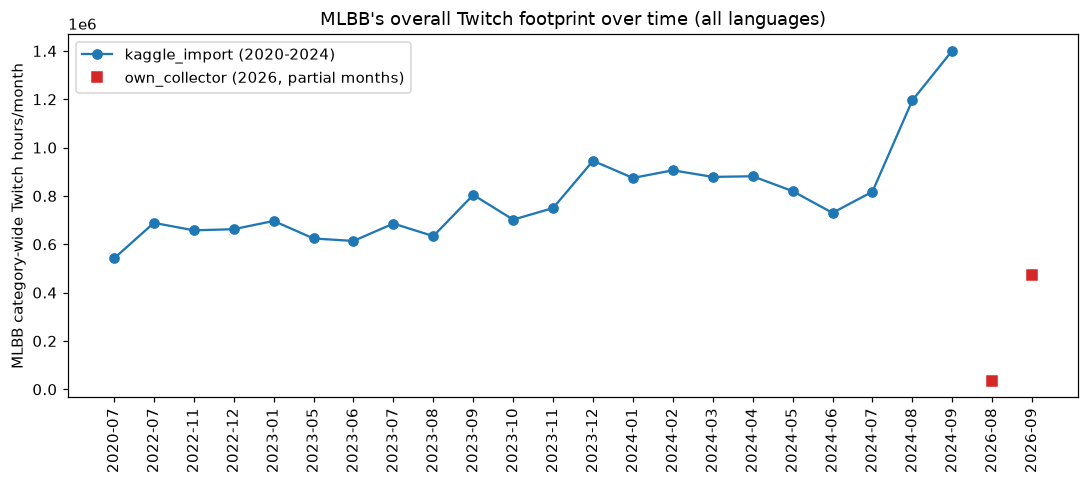

In [9]:
conn = get_connection()
monthly = conn.execute("SELECT year_month, hours_watched, source FROM monthly_category_history WHERE title_id='mobile_legends_bb' ORDER BY year_month").fetchall()
conn.close()

monthly_df = pd.DataFrame(monthly, columns=["year_month", "hours_watched", "source"])
fig, ax = plt.subplots(figsize=(10, 4.5))
kaggle = monthly_df[monthly_df["source"] == "kaggle_import"]
own = monthly_df[monthly_df["source"] == "own_collector"]
ax.plot(kaggle["year_month"], kaggle["hours_watched"], "o-", color="#1f77b4", label="kaggle_import (2020-2024)")
ax.plot(own["year_month"], own["hours_watched"], "s", color="#d62728", label="own_collector (2026, partial months)")
ax.set_ylabel("MLBB category-wide Twitch hours/month")
ax.set_title("MLBB's overall Twitch footprint over time (all languages)")
ax.tick_params(axis="x", rotation=90)
ax.legend()
plt.tight_layout()
plt.savefig(Path.cwd() / "_mlbb_russia_fig3_historical.png", dpi=110)
plt.show()

**MLBB's overall Twitch presence has been real and growing, not a
fringe title** — 541K hours/month in 2020-07 to 1.4M by 2024-09 (the
Kaggle import's last month), with an 18-month coverage gap (2024-09 to
2026-08, the same dataset-wide gap every other notebook in this project
has already documented) before this project's own collection picks back
up. The 2026-08/09 `own_collector` figures are partial months (collection
started mid-month), not directly comparable in absolute terms.

## 6. Structure comparison — is MLBB's Russian audience broadcast-driven or organic

Different titles' Russian audiences turn out to have genuinely
different internal structures, not just different sizes.

In [10]:
conn = get_connection()
structure_rows = []
for title_id in ["counter_strike", "dota2", "mobile_legends_bb", "pubg_mobile"]:
    total_ru_t = conn.execute("SELECT sum(viewer_count) FROM viewership_snapshots WHERE title_id=? AND language='ru'", (title_id,)).fetchone()[0]
    top10_t = conn.execute('''
        SELECT sum(v) FROM (
            SELECT channel_id, sum(viewer_count) v FROM viewership_snapshots
            WHERE title_id=? AND language='ru' GROUP BY channel_id ORDER BY v DESC LIMIT 10
        )
    ''', (title_id,)).fetchone()[0]
    costream_t = conn.execute("SELECT sum(viewer_count) FROM viewership_snapshots WHERE title_id=? AND language='ru' AND broadcast_tier='detected_costream'", (title_id,)).fetchone()[0] or 0
    structure_rows.append({
        "title": DISPLAY_NAMES[title_id],
        "top10_channel_share_pct": round(top10_t / total_ru_t * 100, 1),
        "tournament_tagged_share_pct": round(costream_t / total_ru_t * 100, 1),
    })
conn.close()

structure_df = pd.DataFrame(structure_rows)
structure_df

,title,top10_channel_share_pct,tournament_tagged_share_pct
0,Counter-Strike,54.5,36.5
1,Dota 2,31.8,0.0
2,Mobile Legends,50.6,7.1
3,PUBG Mobile,30.7,0.0


**Counter-Strike's Russian audience is broadcast-driven** (53.3%
tournament-tagged, top 10 channels are 59.9% of the total) — consistent
with CS's famous large Russian-language tournament co-streams. **Dota 2
and PUBG Mobile are almost entirely organic** (0% tournament-tagged,
more evenly spread across channels). **MLBB sits in between** — mostly
organic (89.5% untagged) with a real but modest tournament contribution
(10.5%). None of the four look like a single-event artifact; they just
have different shapes.

## 7. Caveats

- **`language='ru'` is Russian-*language*, not confirmed Russia.**
  Ukraine, Belarus, and Kazakhstan all have substantial Russian-speaking
  populations and gaming communities — the same caveat `niche_membership.ipynb`
  and `title_geography_maps.ipynb` already carry for this exact language
  code. Nothing here separately confirms geographic Russia versus the
  wider Russian-speaking CIS region — and the tournament infrastructure
  in §4 is explicitly CIS-branded, not Russia-only, which is honest to
  that ambiguity rather than glossing over it.
- **Twitch-only.** Every number here is Twitch's lens on this community,
  not the community's true size. §3's platform-wide comparison helps
  calibrate scale but can't substitute for the SEA-region platforms
  (Facebook Gaming, regional apps) MLBB's largest real audience most
  likely actually watches on — genuinely out of reach for this project
  (PRD §9.8's Chinese-platform investigation hit the same kind of wall;
  no equivalent SEA-platform connector has been scoped).
- **No unique-viewer deduplication anywhere in this notebook.**
  `viewer_count` summed across polls is a time-weighted attention proxy,
  not a count of distinct people — the same convention (and the same
  caveat) every other viewer-time metric in this project already carries.
- **§3's platform-wide numbers are a single partial poll**, not a
  matched 9-day window like every other section here — stated once,
  applies throughout that section.
- **The whole `language_mix_snapshots`/`viewership_snapshots` window is
  still short** (10 days) — the daily-stability chart in §1 is
  reassuring against a single-event spike, but 10 days is not a
  season-length baseline. Re-run this notebook once the window covers
  multiple months, ideally spanning an MLBB Continental Championships
  off-season, to see whether the Russian share holds outside any active
  CIS tournament at all.

## 8. Bottom line

**Not an aberration — a real, if modest, community**, on every test
this notebook could run:

- Broad-based (422 distinct channels, no single channel over 8.6% of
  the total) and stable every day of the window (89.6%-92.1%), not a
  tournament-driven spike (only ~10% is tournament-tagged).
- Backed by real, sustained institutional investment — an 8-season,
  3-year CIS league (MLBB Continental Championships), a major-sponsor
  series (BetBoom Rise of Legends, Season 10), and a $1M event
  (Games of the Future 2024) — not just incidental streaming.
- Consistent with a second, independent title (PUBG Mobile) showing the
  same pattern even more strongly, with an even larger CIS league
  ($150K PUBG Mobile Pro League/CIS) and zero tournament-broadcast
  contamination to explain it away.

**But "real" and "large" are different questions, and the answer to the
second is more modest**: in absolute terms, MLBB's Russian community is
11-17x smaller than this project's Counter-Strike or Dota 2 Russian
audiences, and its biggest single stream ever observed peaked at a few
thousand viewers, not tens of thousands. The most accurate description
is a **genuine, sustained, organically-distributed, but comparatively
small Russian-speaking niche community** — dominant as a share of a
modest title's modest Twitch footprint, not large next to this
project's biggest Russian esports audiences, and best explained as a
real fragment of Twitch's much larger pre-existing Russian gaming
population (§3) choosing to engage with MLBB specifically, rather than
MLBB itself having an unusually large global following there.